# End-to-End Pipeline Test: Leaf Detection + Disease Classification

This notebook demonstrates the complete end‑to‑end pipeline on a **single static image**:
1) leaf localization (ESPDet‑Pico)
2) leaf cropping
3) disease classification (MobileNetV2)

The pipeline is designed for a **rectangular input size of 416×320 (w×h)** and tuned for the deployment constraints of the ESP32 device.


## Setup and Inputs

**Required files for this demo**
- A test image (e.g., `IMG_1103.jpg`)
- Trained leaf detector weights (e.g., `best.pt`)
- Trained disease classifier weights (e.g., `mobilenet_128.pth`)

Update the paths in the next code cell to match your local files.


In [80]:

from pathlib import Path
# Static image path
imgPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/IMG_1103.jpg")

# ROI: Leaf detector (Espdet_pico): ESP specific optimized yolo1n model (PyTorch .pt)
leafDetectorPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/runs/detect/train/weights/best.pt")
#leafDetectorPath = Path("/home/ubuntu/OUTPUT/runs/detect/train/weights/best.pt")
# MobileNet disease classifier (PyTorch .pth)
mobileNetPath = Path("/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth")

# Leaf Detection threshold
DET_CONF_THRESH = 0.25

# Training used: ['Black_rot', 'Esca', 'Leaf_blight', 'Healthy'] (alphabetical from ImageFolder)
DISEASE_CLASSES = ["Black_rot", "Esca", "Healthy", "Leaf_blight"]

# Classifier input size
CLASSIFIER_INPUT_SIZE = 128  

# Outputs
OUT_DIR = Path("/home/ubuntu/edge-ai-vineyard-monitoring/outputs_demo")
CROPS_DIR = OUT_DIR / "crops"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

print("Image:", imgPath)
print("Detector:", leafDetectorPath)
print("Classifier:", mobileNetPath)
#print("Disease Classes (training order):", DISEASE_CLASSES)
#print("Outputs:", OUT_DIR)


Image: /home/ubuntu/edge-ai-vineyard-monitoring/IMG_1103.jpg
Detector: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/runs/detect/train/weights/best.pt
Classifier: /home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/finetuned_mobilenet_128.pth


## Imports and Helper Functions

All libraries and small utility functions are loaded once here so they can be reused across the notebook without repetition.


In [81]:
# ==== Imports & small utilities ====
import os, time, json
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms

# Utility to show RGB images
# Visualize RGB image
def show_rgb(img_rgb, title=None, figsize=(10,6)):
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

# Ensure that a path exists
def ensure_exists(p: Path, what: str):
    if not p.exists():
        raise FileNotFoundError(f"{what} not found: {p}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## Input Size and Training Configuration Check

This step verifies that the detection model was trained with **rectangular inputs**.
We read `args.yaml` from the training run to confirm the intended size (**[320, 416]** = height × width)
and print the input image shape so we can see how much resizing/letterboxing will be applied.


In [79]:

from pathlib import Path
import yaml
from PIL import Image
# Load and print input image size
img = Image.open(imgPath)
print("Input image size:", img.size)  # (width, height)

# Load training args to get image size and rect flag
args = yaml.safe_load(Path("/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/runs/detect/train/args.yaml").read_text())
print("imgsz =", args["imgsz"]) # training input size
print("rect  =", args["rect"]) # rectangular training flag


Input image size: (3264, 2448)
imgsz = [320, 416]
rect  = True


## Stage 1 — Leaf Localization (ESPDet‑Pico)

In this stage, the detection model locates leaves in the input image.
Detections are filtered by confidence, then passed to the next stage for cropping.

**Key settings**
- Input size: **416×320** (width×height)
- Preprocess: letterbox to preserve aspect ratio
- Postprocess: confidence thresholding before cropping


In [ ]:
# ==== Load ESPDet-Pico leaf detector ====

# verify  the input image and leaf detector paths exist
ensure_exists(imgPath, "Input image")
ensure_exists(leafDetectorPath, "Detector weights")

# Add leaf_detection to sys.path so we can import nn.esp_tasks
import sys
import os

# Add leaf_detection to sys.path
leaf_detection_root = "/home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection"
if leaf_detection_root not in sys.path:
    sys.path.insert(0, leaf_detection_root)
    print(f" Added to sys.path: {leaf_detection_root}")

# Verify the module if the nn exists
nn_path = os.path.join(leaf_detection_root, "nn", "esp_tasks.py")
if not os.path.exists(nn_path):
    raise FileNotFoundError(f"esp_tasks.py not found at: {nn_path}")
print(f" Verified esp_tasks.py exists at: {nn_path}")

from ultralytics import YOLO

# ESPDet-Pico special: patch Ultralytics parser
try:
    from nn.esp_tasks import custom_parse_model
    import ultralytics.nn.tasks as tasks
    tasks.parse_model = custom_parse_model
    print(" Patched Ultralytics parse_model with custom_parse_model (ESPDet-Pico)")
except Exception as e:
    raise RuntimeError(
        "Failed to import/patch custom_parse_model for ESPDet-Pico. "
        f"Make sure 'nn/esp_tasks.py' exists in {leaf_detection_root}\n"
        f"Original error: {e}"
    )

detector = YOLO(str(leafDetectorPath))
detector.model.to(device).eval()
print(" Detector loaded. Classes:", detector.names)

 Verified esp_tasks.py exists at: /home/ubuntu/edge-ai-vineyard-monitoring/leaf_detection/nn/esp_tasks.py
 Patched Ultralytics parse_model with custom_parse_model (ESPDet-Pico)
 Detector loaded. Classes: {0: 'leaf'}


## Run Leaf Detection and Annotate

This cell runs inference on the input image,
filters detections by confidence, and draws bounding boxes for visualization.
The resulting annotated image is saved in the disk.


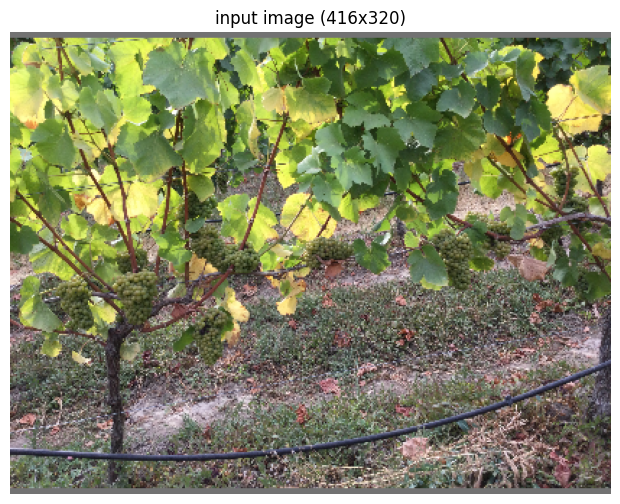

Detector latency: 18.12 ms
Detections kept (conf >= 0.25): 41


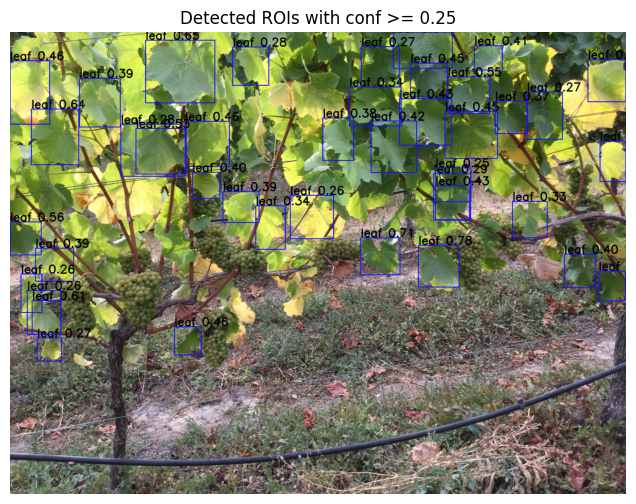

In [82]:
# ==== Run detection, filter by confidence threshold, annotate + save ====

# Read input image
img_bgr = cv2.imread(str(imgPath))
if img_bgr is None:
    raise RuntimeError(f"Failed to read image: {imgPath}")

img_rgb_orig = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Detection input (ESPDet-Pico expects 416x320 => (h=320, w=416))
from ultralytics.data.augment import LetterBox

# Detection input (ESPDet-Pico expects 416x320 => (h=320, w=416))
lb = LetterBox(new_shape=(320, 416), auto=False, scaleup=False)
img_rgb_det = lb(image=img_rgb_orig)

#show_rgb(img_rgb_orig, "Original image")
show_rgb(img_rgb_det, "input image (416x320)")


t0 = time.perf_counter()
# Use Ultralytics predict; ESPDet-Pico uses same Results container once loaded with custom parser
results = detector.predict(source=img_bgr, imgsz=[320, 416], verbose=False)
 # pass ndarray to avoid color confusion
t1 = time.perf_counter()

res = results[0]
if res.boxes is None or len(res.boxes) == 0:
    print("No detections.")
    detections = []
else:
    boxes = res.boxes.xyxy.cpu().numpy()
    confs = res.boxes.conf.cpu().numpy()
    clss  = res.boxes.cls.cpu().numpy().astype(int)

    # confidence-threshold-only filtering
    keep = confs >= DET_CONF_THRESH
    boxes, confs, clss = boxes[keep], confs[keep], clss[keep]

    detections = []
    for i, (xyxy, cf, ci) in enumerate(zip(boxes, confs, clss)):
        x1,y1,x2,y2 = [int(round(v)) for v in xyxy.tolist()]
        # clamp
        h,w = img_bgr.shape[:2]
        x1,y1 = max(0,x1), max(0,y1)
        x2,y2 = min(w-1,x2), min(h-1,y2)
        detections.append({
            "leaf_id": i,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "det_conf": float(cf),
            "det_class_id": int(ci),
            "det_class_name": str(detector.names.get(int(ci), str(ci)))
        })

print(f"Detector latency: {(t1-t0)*1000:.2f} ms")
print(f"Detections kept (conf >= {DET_CONF_THRESH}): {len(detections)}")

# Annotate and save
annot_bgr = img_bgr.copy()
for d in detections:
    x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
    label = f"{d['det_class_name']} {d['det_conf']:.2f}"
    cv2.rectangle(annot_bgr, (x1,y1), (x2,y2), (255,20,20), 4)
    cv2.putText(annot_bgr, label, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 2, (0,0,0), 5)

annot_path = OUT_DIR / "annotated_detections.jpg"
cv2.imwrite(str(annot_path), annot_bgr)
show_rgb(cv2.cvtColor(annot_bgr, cv2.COLOR_BGR2RGB), f"Detected ROIs with conf >= {DET_CONF_THRESH}")


## Stage 2 — Crop Detected Leaves

Each detected leaf is cropped from the original image and stored on disk.
These cropped regions form the input batch for the disease classifier.


**Cropping policy**
- Only detections above the confidence threshold are saved.
- Crops are written to the `leaf_crops/` directory for later use.


In [ ]:
# ==== Crop detected leaves and save ====
crop_paths = []
for d in detections:
    x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
    crop_bgr = img_bgr[y1:y2, x1:x2].copy()
    if crop_bgr.size == 0:
        continue
    crop_name = f"leaf_{d['leaf_id']:03d}_det_{d['det_conf']:.2f}.jpg"
    crop_path = CROPS_DIR / crop_name
    cv2.imwrite(str(crop_path), crop_bgr)
    d["crop_path"] = str(crop_path)
    crop_paths.append(crop_path)

print(f"Saved {len(crop_paths)} crops to: {CROPS_DIR}")


Saved 41 crops to: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_demo/crops


Showing cropped leaves with det conf >= threshold (0.25)


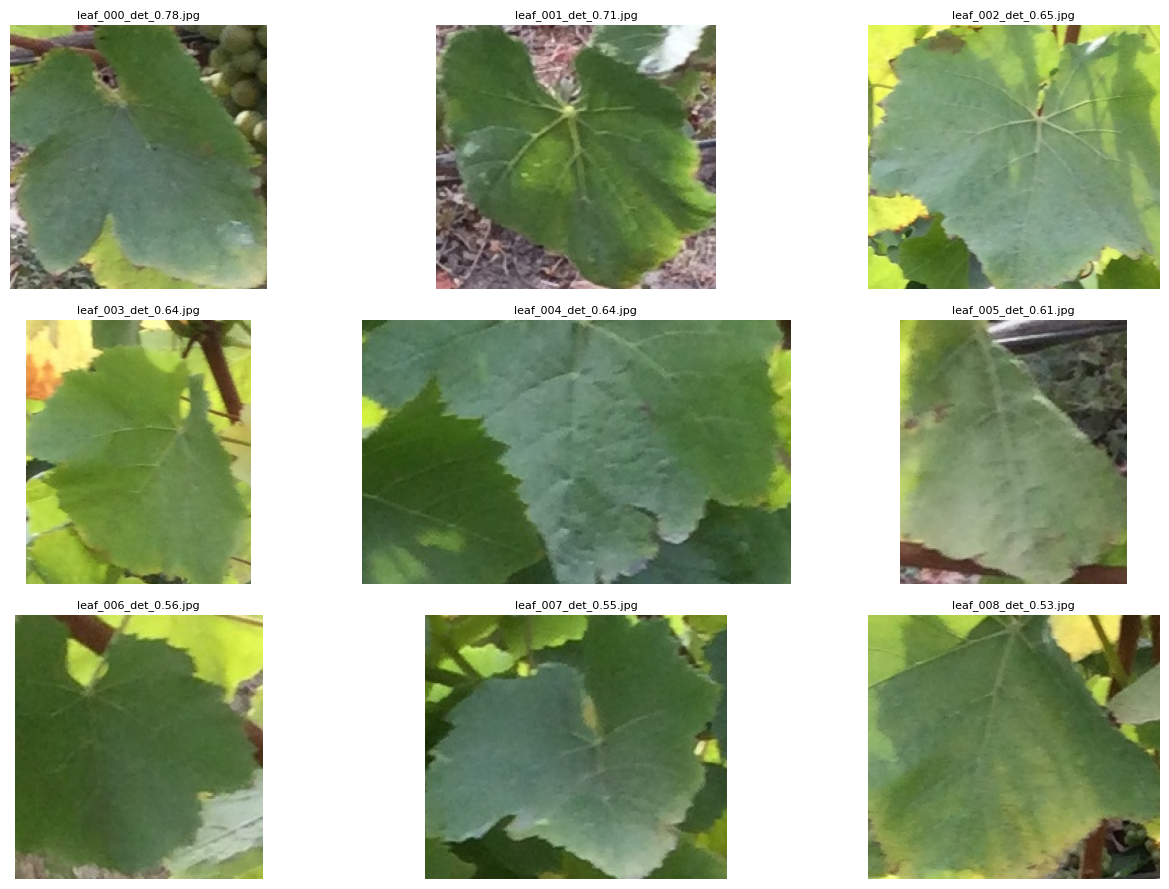

In [72]:
# ==== Show cropped leaves ====
if len(crop_paths) == 0:
    print("No crops to display.")
else:
    print(f"Showing cropped leaves with det conf >= threshold ({DET_CONF_THRESH})")
    n = len(crop_paths)
    cols = 3
    rows = 3
    plt.figure(figsize=(14, rows*3))
    for i, p in enumerate(crop_paths):
        crop_bgr = cv2.imread(str(p))
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i+1)
        plt.imshow(crop_rgb)
        plt.title(p.name, fontsize=8)
        plt.axis("off")
        if i>=8:
            break
    plt.tight_layout()
    plt.show()


## Stage 3 — Disease Classification (MobileNetV2)

Each cropped leaf is resized and normalized, then passed through a MobileNetV2
classifier to predict the disease class.

**Outputs**
- Per‑leaf predicted class + confidence
- Annotated image saved to disk

In the following cells, crops are preprocessed, batched, and fed into the classifier.


In [ ]:
# ==== Prepare inference dataset (the cropped leaves) and dataloader for classifier ====
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

BATCH_SIZE = 8

class InferenceCropsDataset(Dataset):
    """Dataset for inference on cropped leaf images (no labels)."""
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform
    
    def __getitem__(self, index):
        img_path = self.image_paths[index]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, str(img_path)  # return image and path
    
    def __len__(self):
        return len(self.image_paths)

# Inference transform (same as training validation transform)
inference_transform = transforms.Compose([
    transforms.Resize(144),
    transforms.CenterCrop(128),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#print("--- Inference Transform ---")
#print(inference_transform)

# Create dataset from the cropped images
if len(crop_paths) == 0:
    print("No crops available for inference.")
    inference_dataset = None
    inference_loader = None
else:
    inference_dataset = InferenceCropsDataset(crop_paths, inference_transform)
    inference_loader = DataLoader(
        inference_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    print(f"Inference dataset: {len(inference_dataset)} images ({len(inference_loader)} batches)")


Inference dataset: 41 images (6 batches)


## Load Disease Classifier

Load the MobileNetV2 model weights and the class label mapping used during training.


In [ ]:
# 

# ==== Load MobileNet disease classifier ====
ensure_exists(mobileNetPath, "MobileNet weights")

def build_mobilenet(num_classes: int):
    # Standard MobileNetV2 backbone
    m = models.mobilenet_v2(weights=None)
    m.classifier[1] = torch.nn.Linear(m.classifier[1].in_features, num_classes)
    return m
# Build and load weights
classifier = build_mobilenet(len(DISEASE_CLASSES))

ckpt = torch.load(str(mobileNetPath), map_location="cpu")
# Support both full-model checkpoints and state_dict checkpoints
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt
# Strip common prefixes
new_sd = {}
for k, v in state_dict.items():
    nk = k
    for pref in ("module.", "model.", "mobilenet."):
        if nk.startswith(pref):
            nk = nk[len(pref):]
    new_sd[nk] = v

missing, unexpected = classifier.load_state_dict(new_sd, strict=False)
#print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))

classifier.to(device).eval()
print("Disease classifier model  loaded on", device)


Disease classifier model  loaded on cuda


## Single‑Leaf Inference ( on one crop)

Run classification on one cropped leaf to verify preprocessing, model loading,
and output formatting before batching the full set.


In [ ]:
# ==== Run Disease classification inference ====
print("Testing classifier with a sample crop [1]...")
if len(crop_paths) > 1:
    test_crop = Image.open(crop_paths[1]).convert('RGB')
    test_tensor = inference_transform(test_crop).unsqueeze(0).to(device)
    
    with torch.no_grad():
        test_logits = classifier(test_tensor)
        test_probs = torch.softmax(test_logits, dim=1)[0]
    
    print("\nClass probability distribution for first crop:")
    print("-" * 50)
    for i, (cls, prob) in enumerate(zip(DISEASE_CLASSES, test_probs)):
        print(f"{i}: {cls:15s} -> {prob.item():.4f} ({prob.item()*100:.2f}%)")
    
    pred_idx = test_probs.argmax().item()
    print(f"\nPredicted: {DISEASE_CLASSES[pred_idx]} (confidence: {test_probs[pred_idx].item():.4f})")
else:
    print("No crops available for testing")


Testing classifier with a sample crop [1]...

Class probability distribution for first crop:
--------------------------------------------------
0: Black_rot       -> 0.1295 (12.95%)
1: Esca            -> 0.2147 (21.47%)
2: Healthy         -> 0.5937 (59.37%)
3: Leaf_blight     -> 0.0621 (6.21%)

Predicted: Healthy (confidence: 0.5937)


## Disease Classification Inference on All Crops

Each saved crop is preprocessed and classified. Results are collected for
visualization and reporting.


In [69]:
# ==== Run disease classification on all crops using inference_loader ====
if inference_dataset is None or len(inference_dataset) == 0:
    print("No croped images, no classification.")
    preds_df = pd.DataFrame()
else:
    print(f"Running inference on {len(inference_dataset)} crops...")
    
    all_preds = []
    all_confs = []
    all_probs = []
    all_paths = []
    
    with torch.no_grad():
        t0 = time.perf_counter()
        for batch_imgs, batch_paths in inference_loader:
            batch_imgs = batch_imgs.to(device)
            logits = classifier(batch_imgs)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            
            top_idx = probs.argmax(axis=1)
            top_conf = probs.max(axis=1)
            
            all_preds.extend([DISEASE_CLASSES[int(i)] for i in top_idx])
            all_confs.extend(top_conf.tolist())
            all_probs.extend(probs.tolist())
            all_paths.extend(batch_paths)
        
        if device == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    
    print(f"Classifier latency (total {len(inference_dataset)} images): {(t1-t0)*1000:.2f} ms")
    print(f"Average per image: {(t1-t0)*1000/len(inference_dataset):.2f} ms")
    
    # Update detections with disease predictions
    for d in detections:
        if "crop_path" not in d:
            continue
        crop_path_str = str(d["crop_path"])
        # Find matching prediction
        try:
            idx = all_paths.index(crop_path_str)
            d["disease_class"] = all_preds[idx]
            d["disease_conf"] = all_confs[idx]
            d["disease_probs"] = all_probs[idx]
        except ValueError:
            print(f"Warning: No prediction found for {crop_path_str}")
    
    # Create results dataframe
    preds_df = pd.DataFrame([{
        "leaf_id": d["leaf_id"],
        "det_conf": d["det_conf"],
        "crop_path": d.get("crop_path", ""),
        "disease_class": d.get("disease_class", ""),
        "disease_conf": d.get("disease_conf", np.nan),
    } for d in detections if "crop_path" in d])
    
    display(preds_df.sort_values(["disease_conf", "det_conf"], ascending=False).reset_index(drop=True))
    
    # Save results
    csv_path = OUT_DIR / "leaf_predictions.csv"
    json_path = OUT_DIR / "leaf_predictions.json"
    preds_df.to_csv(csv_path, index=False)
    preds_df.to_json(json_path, orient="records", indent=2)
    print("Saved:", csv_path)
    print("Saved:", json_path)


Running inference on 41 crops...
Classifier latency (total 41 images): 294.19 ms
Average per image: 7.18 ms


,leaf_id,det_conf,crop_path,disease_class,disease_conf
0,6,0.559495,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.924121
1,3,0.644152,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.910697
2,28,0.330294,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.908192
3,7,0.547219,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.904556
4,24,0.375555,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.895021
5,23,0.390262,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.890748
6,26,0.344001,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.889983
7,11,0.455899,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.887789
8,2,0.648334,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Healthy,0.883753
9,38,0.260255,/home/ubuntu/edge-ai-vineyard-monitoring/outpu...,Leaf_blight,0.849800


Saved: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_demo/leaf_predictions.csv
Saved: /home/ubuntu/edge-ai-vineyard-monitoring/outputs_demo/leaf_predictions.json


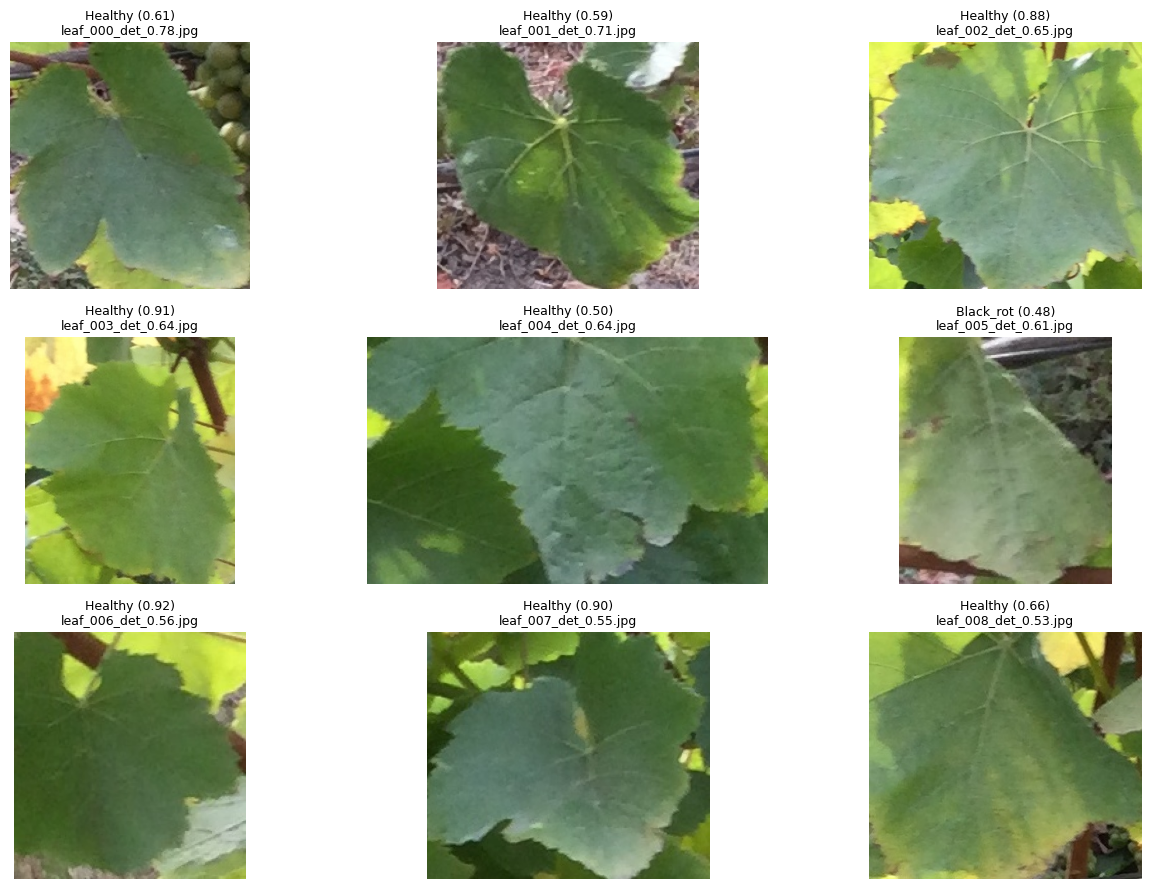

✓ Displayed 8 sample predictions


In [70]:
# ==== Visualize sample predictions ====
import random

if len(detections) > 0:
    # Select random samples with predictions
    samples_with_pred = [d for d in detections if "disease_class" in d and "crop_path" in d]
    
    if len(samples_with_pred) > 0:
        num_samples = min(8, len(samples_with_pred))
        sample_dets = random.sample(samples_with_pred, num_samples)
        
        images, preds, paths = [], [], []
        for d in detections:
            img_path = Path(d["crop_path"])
            img_pil = Image.open(img_path).convert('RGB')
            pred_label = f"{d['disease_class']} ({d['disease_conf']:.2f})"
            
            images.append(img_pil)
            preds.append(pred_label)
            paths.append(img_path.name)
        
        # Visualize 
        cols = 3
        rows = 3
        fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
        axes = np.atleast_1d(axes).flatten()
        
        for ax, img, pred, path in zip(axes, images, preds, paths):
            ax.imshow(img)
            ax.set_title(f"{pred}\n{path}", fontsize=9)
            ax.axis("off")
        
        for ax in axes[len(images):]:
            ax.axis("off")
        
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Displayed {num_samples} sample predictions")
    else:
        print("No predictions available to visualize.")
else:
    print("No detections to visualize.")


## Visualization of Predicted Classes

visualize predictions and save annotated outputs,
including disease class overlaid on the detected leaves.


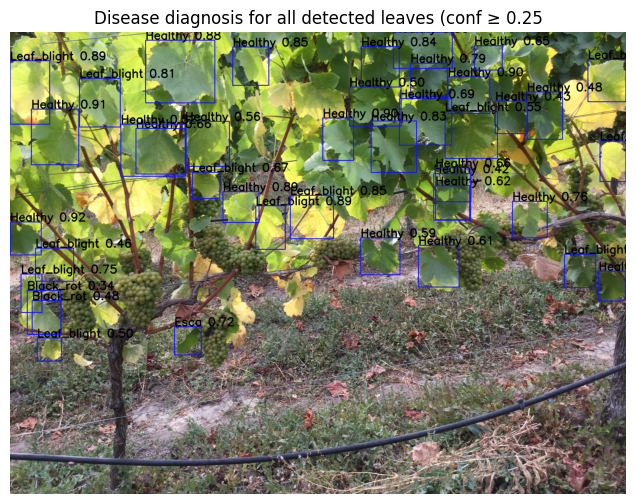

In [71]:
# ==== Annotate image with disease predictions and save ====
if len(detections) == 0:
    print("No detections to annotate.")
else:
    annot2 = img_bgr.copy()
    for d in detections:
        x1,y1,x2,y2 = d["x1"], d["y1"], d["x2"], d["y2"]
        if "disease_class" in d:
            label = f"{d['disease_class']} {d['disease_conf']:.2f}"
            color = (0,0,0)
        else:
            label = f"det {d['det_conf']:.2f}"
            color = (0,0,0)
        color2 = (255,20,20)
        cv2.rectangle(annot2, (x1,y1), (x2,y2), color2, 4)
        cv2.putText(annot2, label, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 2, color, 5)

    out_path = OUT_DIR / "annotated_detections_with_disease.jpg"
    cv2.imwrite(str(out_path), annot2)
    show_rgb(cv2.cvtColor(annot2, cv2.COLOR_BGR2RGB), f"Disease diagnosis for all detected leaves (conf ≥ {DET_CONF_THRESH}")


## Outputs

Artifacts are saved under `outputs_demo`:
- `annotated_detections.jpg` (leaf boxes)
- `leaf_crops/` (cropped leaf images)
- `annotated_disease.jpg` (disease labels)
